# Exploratory Data Analysis Report
### NU High School Data Platform — MSDS 498 Capstone

**Week 4 Deliverable — 2026-07-17**

This report covers exploratory data analysis on the platform's master dataset, identifies
data gaps, assesses the risks those gaps create, analyzes their impact on the final project,
and closes with insights and recommendations. All numbers and charts below are computed live
from the project's actual data (`csv_exports/`) — nothing here is illustrative or hypothetical.

**Scope**: the analysis draws on `benchmarking_v1_2026-07-17.csv` (the final joined artifact —
53,966 schools nationwide, after the rigor classification, clustering, and benchmarking passes
described in `docs/RIGOR_CLASSIFICATION.md`, `docs/CLUSTERING.md`, and `docs/BENCHMARKING.md`)
and `clustering_v1_2026-07-17.csv` for the clustering-specific section.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

df = pd.read_csv("../csv_exports/benchmarking_v1_2026-07-17.csv", low_memory=False)
cluster_df = pd.read_csv("../csv_exports/clustering_v1_2026-07-17.csv", low_memory=False)

print(f"Main dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Clustering dataset: {cluster_df.shape[0]:,} rows x {cluster_df.shape[1]} columns")

Main dataset: 34,392 rows x 67 columns
Clustering dataset: 34,392 rows x 72 columns


## 1. Dataset Overview

The master dataset consolidates ten public data sources (NCES, Census, CRDC, College Board,
IB, ISBE, CPS, NAEP) plus the client's own NU organizational export, joined primarily on CEEB
code. The row below is the fully-joined universe (`schools_org_all`, 53,966 rows: public
schools, private schools, and org-only rows with no school-side match); this report's
descriptive statistics use the version restricted to actual public+private high schools with
enrollment ≥30 (the "cleaning freeze" universe — 34,392 rows, see `docs/TEST_PLAN.md` §1).

Analysis universe: 34,392 schools

Sector breakdown:
sector
public     20620
private    13772


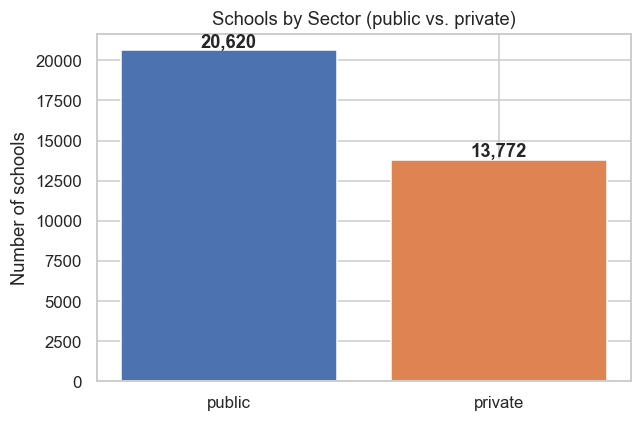

In [2]:
print(f"Analysis universe: {len(df):,} schools\n")
print("Sector breakdown:")
print(df["sector"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(6, 4))
sector_counts = df["sector"].value_counts()
ax.bar(sector_counts.index, sector_counts.values, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Number of schools")
ax.set_title("Schools by Sector (public vs. private)")
for i, v in enumerate(sector_counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Descriptive Statistics

Summary statistics for the core numeric features used across the rigor classification,
funding overlay, and benchmarking components.

In [3]:
key_numeric_cols = [
    "grad_rate_2021", "frl_rate", "child_poverty_saipe",
    "ap_participation", "testtaker_rate", "sat_score_nu",
    "per_resident_child_funding_state_local", "enrollment_9_12",
]
desc = df[key_numeric_cols].describe().T
desc["missing_pct"] = (1 - df[key_numeric_cols].notna().mean()) * 100
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_pct
grad_rate_2021,17420.0,84.55,17.77,0.50,82.00,91.00,95.00,99.50,49.35
frl_rate,17230.0,56.52,26.19,0.12,36.02,54.29,79.07,173.77,49.90
child_poverty_saipe,20923.0,15.56,7.00,2.60,10.50,14.80,19.20,60.70,39.16
ap_participation,12260.0,0.19,0.15,0.00,0.08,0.16,0.26,0.78,64.35
testtaker_rate,18804.0,0.20,0.15,0.00,0.07,0.20,0.28,0.71,45.32
sat_score_nu,11098.0,1148.91,65.17,910.00,1110.00,1150.00,1180.00,1440.00,67.73
per_resident_child_funding_state_local,14340.0,16336.75,6291.12,7842.10,11995.48,14844.88,18920.25,41847.68,58.30
enrollment_9_12,21638.0,703.38,735.85,30.00,170.00,409.00,1034.00,14517.00,37.08


## 3. Data Coverage (Missingness) Analysis

This is the foundation for the data-gaps discussion in Section 6: coverage below 100% is not
inherently a problem (some fields are legitimately source-specific, e.g. IL-only ISBE fields),
but it is exactly what determines which downstream analyses are trustworthy at what scale.

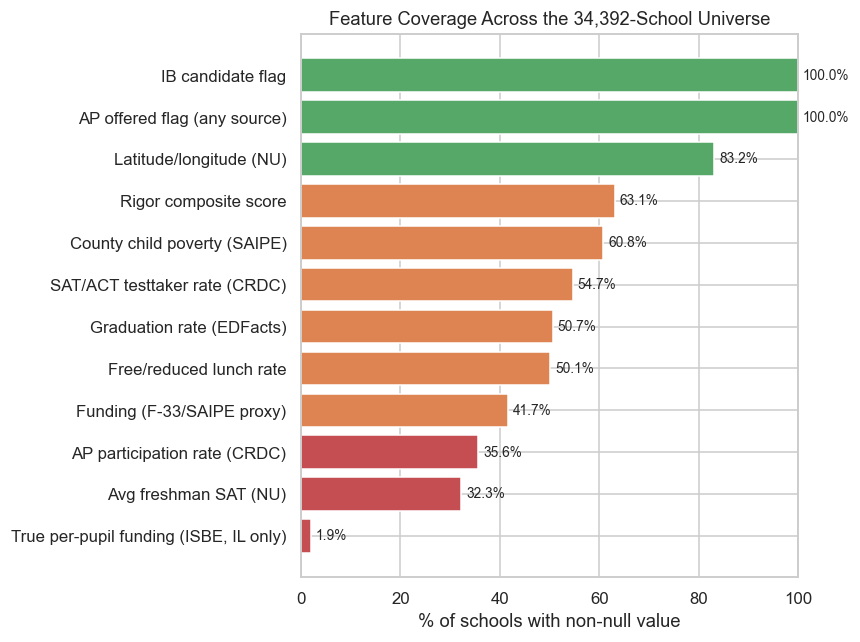

In [4]:
coverage_cols = {
    "grad_rate_2021": "Graduation rate (EDFacts)",
    "frl_rate": "Free/reduced lunch rate",
    "ap_offered": "AP offered flag (any source)",
    "ap_participation": "AP participation rate (CRDC)",
    "testtaker_rate": "SAT/ACT testtaker rate (CRDC)",
    "sat_score_nu": "Avg freshman SAT (NU)",
    "child_poverty_saipe": "County child poverty (SAIPE)",
    "per_resident_child_funding_state_local": "Funding (F-33/SAIPE proxy)",
    "per_pupil_state_local": "True per-pupil funding (ISBE, IL only)",
    "ib_flag_candidate": "IB candidate flag",
    "rigor_score": "Rigor composite score",
    "latitude": "Latitude/longitude (NU)",
}
coverage = pd.Series({label: df[col].notna().mean() * 100 for col, label in coverage_cols.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if v < 40 else "#DD8452" if v < 70 else "#55A868" for v in coverage.values]
ax.barh(coverage.index, coverage.values, color=colors)
ax.set_xlabel("% of schools with non-null value")
ax.set_title("Feature Coverage Across the 34,392-School Universe")
ax.set_xlim(0, 100)
for i, v in enumerate(coverage.values):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Data Distributions

Distributions of the key features feeding the rigor classification and funding overlay.

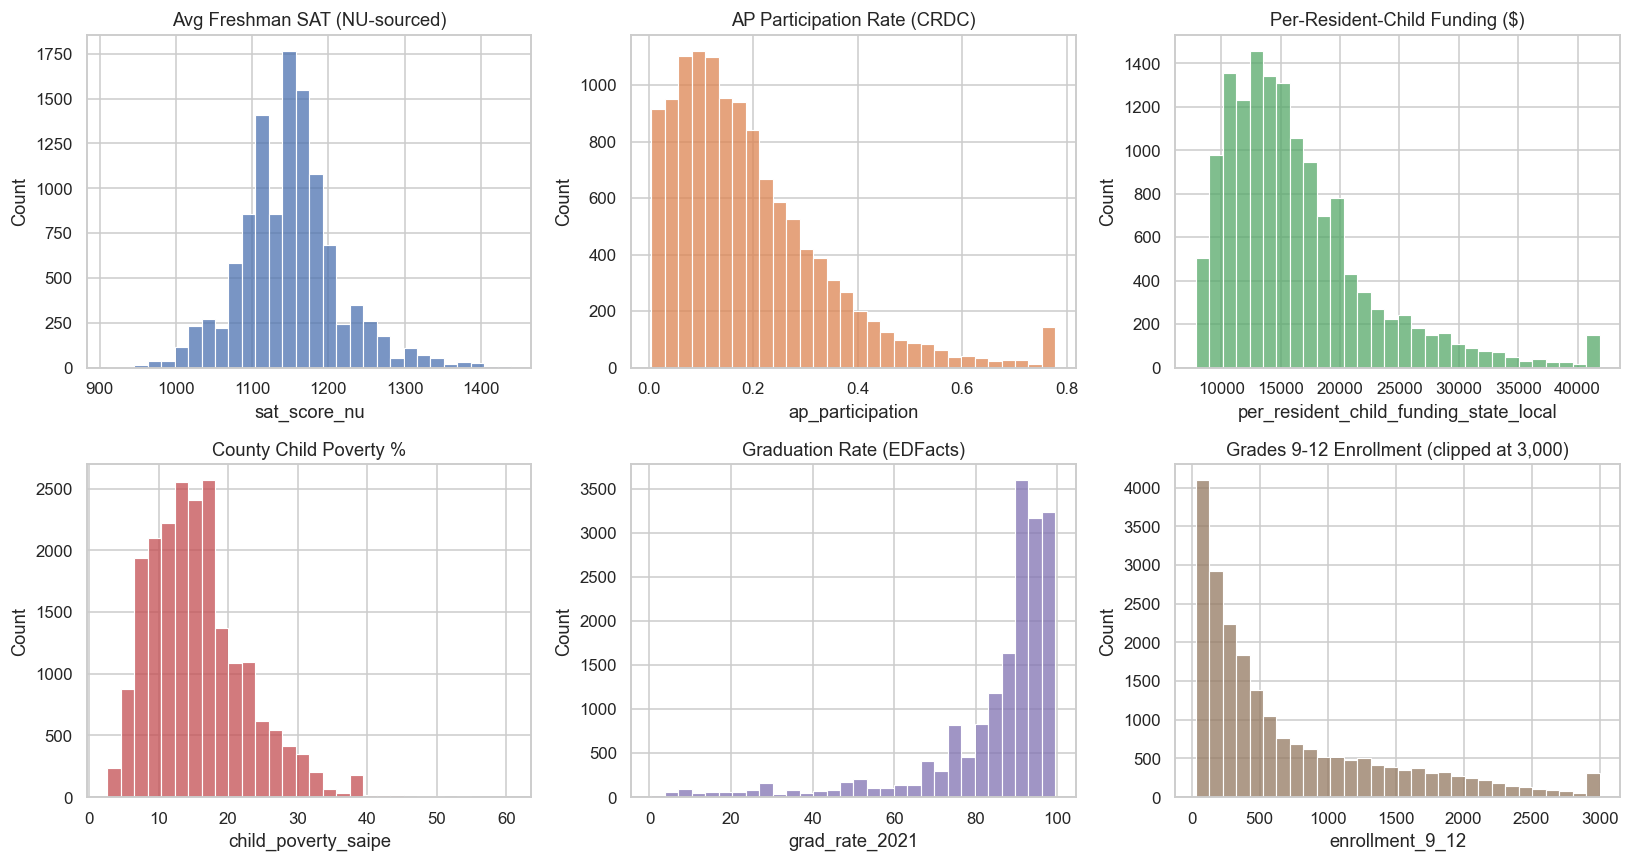

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["sat_score_nu"].dropna(), bins=30, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Avg Freshman SAT (NU-sourced)")

sns.histplot(df["ap_participation"].dropna(), bins=30, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("AP Participation Rate (CRDC)")

sns.histplot(df["per_resident_child_funding_state_local"].dropna(), bins=30, ax=axes[0, 2], color="#55A868")
axes[0, 2].set_title("Per-Resident-Child Funding ($)")

sns.histplot(df["child_poverty_saipe"].dropna(), bins=30, ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("County Child Poverty %")

sns.histplot(df["grad_rate_2021"].dropna(), bins=30, ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Graduation Rate (EDFacts)")

sns.histplot(df["enrollment_9_12"].dropna().clip(upper=3000), bins=30, ax=axes[1, 2], color="#937860")
axes[1, 2].set_title("Grades 9-12 Enrollment (clipped at 3,000)")

plt.tight_layout()
plt.show()

## 5. Public vs. Private: The Real Structural Split

The single most consequential pattern in this dataset: public and private schools have
fundamentally different data availability, not just different values. CRDC (the richest
federal source — AP, dual enrollment, testtaker rates) is a **public-school-only** collection;
private schools depend entirely on what the client's own NU export happens to carry.

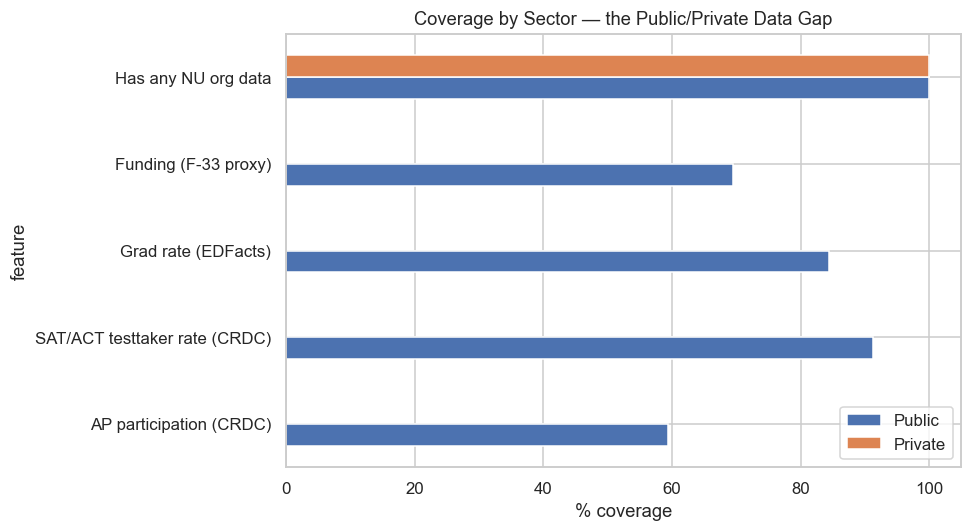

,public_pct,private_pct
feature,,
AP participation (CRDC),59.5,0.0
SAT/ACT testtaker rate (CRDC),91.2,0.0
Grad rate (EDFacts),84.5,0.0
Funding (F-33 proxy),69.5,0.0
Has any NU org data,100.0,100.0


In [6]:
compare_cols = {
    "ap_participation": "AP participation (CRDC)",
    "testtaker_rate": "SAT/ACT testtaker rate (CRDC)",
    "grad_rate_2021": "Grad rate (EDFacts)",
    "per_resident_child_funding_state_local": "Funding (F-33 proxy)",
    "has_nu_data": "Has any NU org data",
}
rows = []
for col, label in compare_cols.items():
    pub = df.loc[df["sector"] == "public", col].notna().mean() * 100
    priv = df.loc[df["sector"] == "private", col].notna().mean() * 100
    rows.append({"feature": label, "public_pct": pub, "private_pct": priv})
sector_cov = pd.DataFrame(rows).set_index("feature")

fig, ax = plt.subplots(figsize=(9, 5))
sector_cov.plot(kind="barh", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xlabel("% coverage")
ax.set_title("Coverage by Sector — the Public/Private Data Gap")
ax.legend(["Public", "Private"])
plt.tight_layout()
plt.show()

sector_cov.round(1)

## 6. Correlation Analysis

Correlation among the academic, funding, and poverty features feeding the rigor and funding
components — this is the same collinearity `docs/CLUSTERING.md` §4.3 quantifies via PCA;
shown here as a heatmap for direct visual inspection.

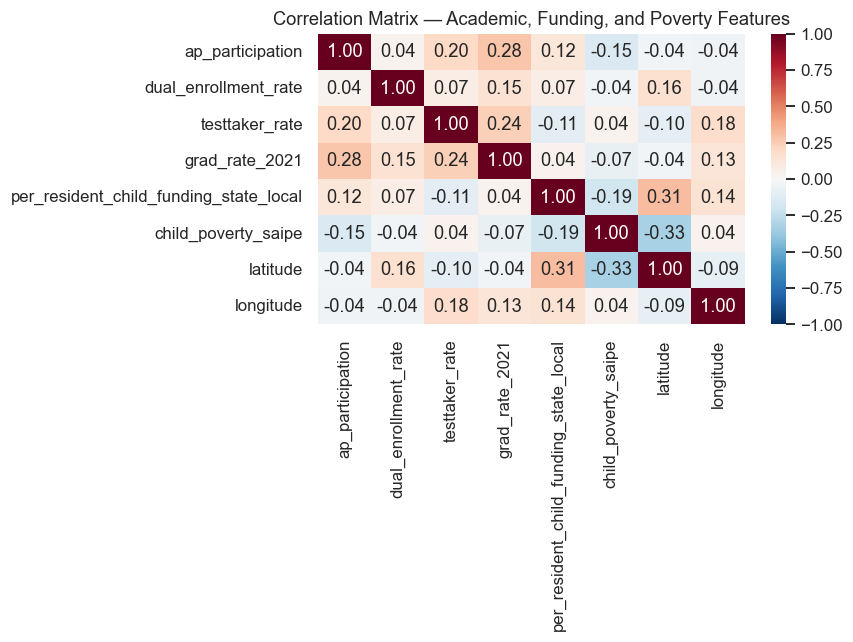

In [7]:
corr_cols = ["ap_participation", "dual_enrollment_rate", "testtaker_rate", "grad_rate_2021",
             "per_resident_child_funding_state_local", "child_poverty_saipe", "latitude", "longitude"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Academic, Funding, and Poverty Features")
plt.tight_layout()
plt.show()

## 7. Rigor Classification Summary

Five-tier composite built from AP/CRDC-coursework/test-participation components (see
`docs/RIGOR_CLASSIFICATION.md` for full methodology, nominal-vs-effective weights, and
sensitivity analysis).

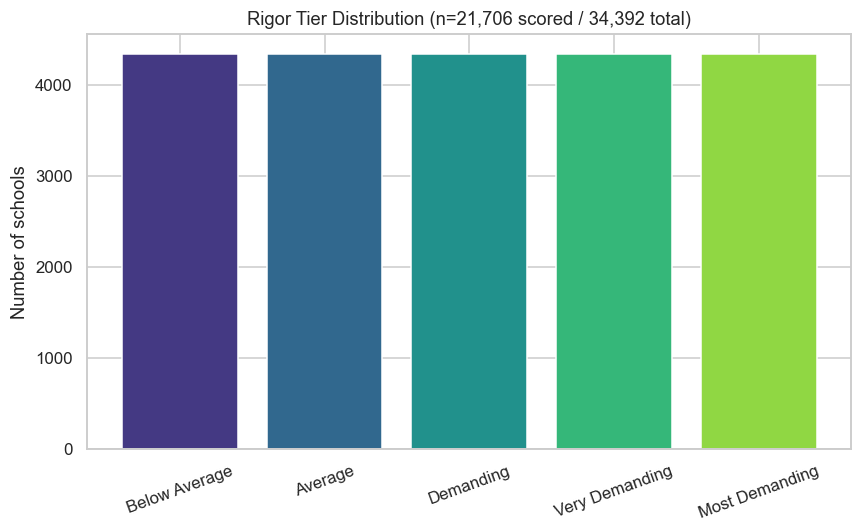

Scored: 21,706 / 34,392 (63.1%)


In [8]:
tier_order = ["Below Average", "Average", "Demanding", "Very Demanding", "Most Demanding"]
tier_counts = df["rigor_tier_label"].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tier_counts.index, tier_counts.values, color=sns.color_palette("viridis", 5))
ax.set_ylabel("Number of schools")
ax.set_title(f"Rigor Tier Distribution (n={int(tier_counts.sum()):,} scored / {len(df):,} total)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(f"Scored: {df['rigor_score'].notna().sum():,} / {len(df):,} ({100*df['rigor_score'].notna().mean():.1f}%)")

## 8. Clustering Summary

K-means clusters (k=4, selected via gap statistic) plotted on the first two principal
components. See `docs/CLUSTERING.md` for the full methodology and the honest finding that
cluster separation is weak (best silhouette score 0.205) — shown visually here as
overlapping, not tightly separated, point clouds.

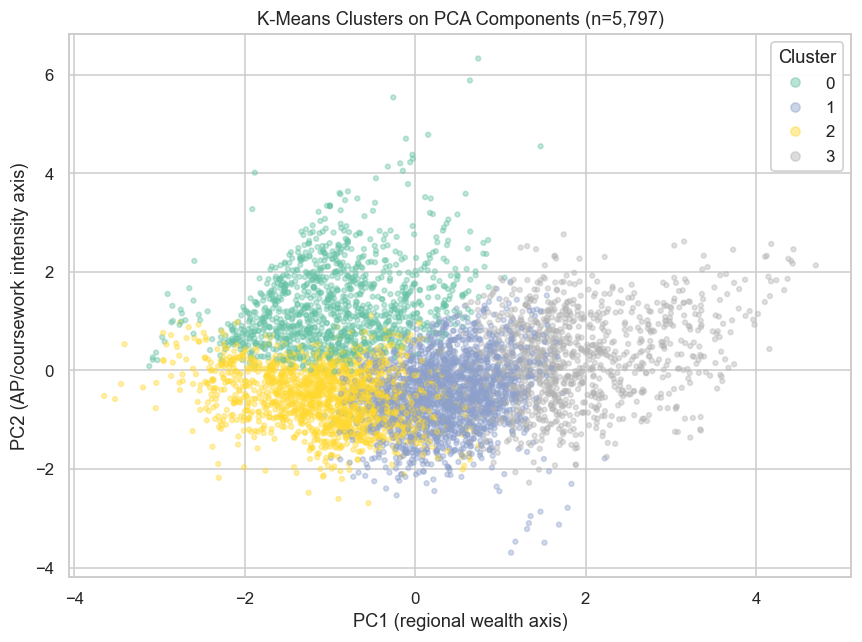

Complete-case coverage for clustering: 5,797 / 34,392 (16.9%)


In [9]:
plot_df = cluster_df.dropna(subset=["pca_component_1", "pca_component_2", "cluster_kmeans"])
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df["pca_component_1"], plot_df["pca_component_2"],
                      c=plot_df["cluster_kmeans"], cmap="Set2", alpha=0.4, s=10)
ax.set_xlabel("PC1 (regional wealth axis)")
ax.set_ylabel("PC2 (AP/coursework intensity axis)")
ax.set_title(f"K-Means Clusters on PCA Components (n={len(plot_df):,})")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

print(f"Complete-case coverage for clustering: {len(plot_df):,} / {len(cluster_df):,} "
      f"({100*len(plot_df)/len(cluster_df):.1f}%)")

## 9. Performance Benchmarking Summary

SAT performance by region and by rigor tier (descriptive only — see `docs/BENCHMARKING.md`
for the full peer-group methodology and the SES-reproduction finding).

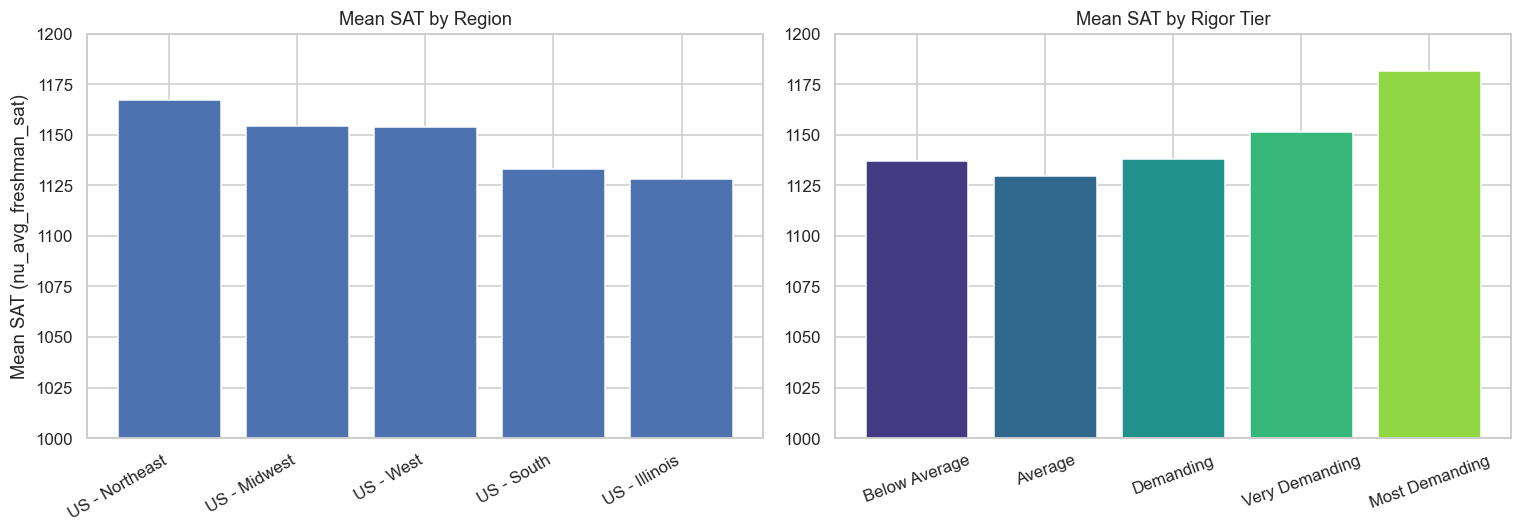

spearman(SAT, poverty)  = -0.385
spearman(rigor tier, poverty) = -0.070


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_sat = df.groupby("us_region")["sat_score_nu"].mean().sort_values(ascending=False)
axes[0].bar(region_sat.index, region_sat.values, color="#4C72B0")
axes[0].set_title("Mean SAT by Region")
axes[0].set_ylabel("Mean SAT (nu_avg_freshman_sat)")
axes[0].set_ylim(1000, 1200)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

tier_sat = df.groupby("rigor_tier_label")["sat_score_nu"].mean().reindex(tier_order)
axes[1].bar(tier_sat.index, tier_sat.values, color=sns.color_palette("viridis", 5))
axes[1].set_title("Mean SAT by Rigor Tier")
axes[1].set_ylim(1000, 1200)
plt.setp(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.show()

print(f"spearman(SAT, poverty)  = {df['sat_score_nu'].corr(df['child_poverty_saipe'], method='spearman'):.3f}")
print(f"spearman(rigor tier, poverty) = {df['rigor_tier_num'].corr(df['child_poverty_saipe'], method='spearman'):.3f}")

## 10. Identification of Data Gaps

Every gap below is drawn directly from the coverage numbers computed above, plus findings
documented in `docs/DATA_DICTIONARY.md`, `docs/EDA_features_joined.md`, and
`docs/BOB_BRIEFING.md` during this project's development.

**Structural gap — private schools.** CRDC (the richest source: AP participation, dual
enrollment, testtaker rates) is public-school-only by federal design. Section 5 shows this
starkly: private schools have near-zero CRDC coverage regardless of school quality. This is
not fixable by better matching — the data simply doesn't exist for private schools at the
federal level. Only the client's own NU export fills this gap, and only where NU has data.

**Vintage/freshness gaps.** Most `nu_*` fields (56 of them) have no confirmed per-variable
measurement date — only the export file's timestamp is known. CRDC's vintage is confirmed
(SY2021-22) for the CRDC *file itself*, but that file arrives bundled inside a teammate's
gitignored export, so its freshness can't be independently re-verified from this repo's own
history (see `docs/DATA_DICTIONARY.md`'s 2026-07-17 update).

**Coverage gaps, quantified (Section 3):** rigor-classifier signal exists for only 63.1% of
the universe; complete data across all 8 clustering features (location + academic + funding +
poverty) exists for only 16.9%; SAT coverage is 32.3%; ACT coverage is 1.2% nationally
(effectively unusable outside Illinois).

**Identifier/linkage gaps.** The `custom_id` field in the client's org export doesn't match
any federal ID system and isn't unique — unusable as a join key. Investigating it surfaced a
separate, more serious finding: at least 62 confirmed (644 suspected) CEEB codes show a
digit-shift corruption pattern, meaning some schools' primary join key may itself be wrong.

**True per-pupil funding gap.** Census F-33 has no enrollment/membership field, and no
verified district-level enrollment source is loaded — the national funding feature is a
population-based proxy (SAIPE school-age residents), not true per-pupil expenditure.

## 11. Assessment of Associated Risks

| Risk | Likelihood | Severity | Evidence |
|---|---|---|---|
| **CRDC access loss changes rigor tiers substantially** | Confirmed, not hypothetical | High | 52.5% of CRDC-covered schools change rigor tier if CRDC signal is removed (`docs/RIGOR_CLASSIFICATION.md`) — quantified, not estimated |
| **Private schools systematically under-represented in rigor/funding features** | Certain (structural) | High | Section 5 above; a platform meant to serve *all* applicants has a built-in blind spot for ~13,900 private high schools |
| **Rigor tier could reproduce socioeconomic ordering, undermining the platform's core value proposition** | Checked, found low | Low (currently) | Rigor-tier/poverty correlation is only -0.070, vs. -0.385 for raw SAT — the risk is real for outcome-style measures but empirically low for this opportunity-structure design |
| **CEEB corruption causes silent school mis-attribution** | Confirmed for 62+ codes | Medium | A corrupted CEEB could cause a school's data to attach to the wrong record, or fail to match at all, without any error being raised |
| **Funding proxy misrepresents true per-pupil spending** | Certain (by construction) | Medium | Population ÷ revenue is not the same denominator as enrolled students; districts with unusual population-to-enrollment ratios (e.g. high private-school attendance in-district) would be most affected |
| **Weak natural cluster structure gets over-interpreted as meaningful school "types"** | Confirmed | Medium | Silhouette score 0.205 (below the conventional 0.25 threshold) — any downstream narrative built on hard cluster boundaries would overstate what the data actually supports |
| **Reproducibility gap: a new team member or grader can't rebuild the full pipeline** | Confirmed, mitigated | Low (after mitigation) | Fixed 2026-07-17 — raw data (~2.6 GB) documented via a shared Drive link rather than left unwritten |

## 12. Impact Analysis and Mitigation Strategies

**CRDC dependency (High severity).** *Impact*: if the Office for Civil Rights (CRDC's steward)
changes access terms — a real possibility already flagged in this project's literature review
— roughly half of currently-tiered schools would need to be re-scored, and their tier could
change. *Mitigation already in place*: the rigor classifier logs which components were
available per school (`rigor_components_available`) so a future CRDC loss is detectable and
auditable, not silent. *Recommended*: monitor CRDC's release cadence and maintain the
NU-only fallback scenario already built and tested.

**Private-school gap (High severity).** *Impact*: any "rigor tier" or benchmarking claim about
private schools rests on a thinner, less-verified data foundation than public schools — a
direct threat to the platform's stated goal of being *more* equitable than Landscape, not
just a replacement for it. *Mitigation*: the sector split is already surfaced everywhere (not
hidden inside an aggregate "all schools" number), and this report documents it explicitly
rather than treating it as a footnote. *Recommended*: state this limitation plainly in any
client-facing deliverable that includes private schools, and treat public/private as two
separate populations for any statistical claim, not one blended one.

**CEEB corruption (Medium severity).** *Impact*: an unknown number of schools (up to 644,
62 confirmed) may have data misattributed via the join key, undermining trust in *any* number
derived from a match. *Mitigation*: flagged via `ceeb_suspected_padding_shift`, not silently
corrected (no reliable way to determine which side of a pair is right). *Recommended*: raise
with whoever owns the source export, since this is an upstream data-entry issue, not something
fixable downstream.

**Funding proxy (Medium severity).** *Impact*: any per-pupil funding comparison between
schools is only as good as the population-based proxy, which could be off in either direction
for specific districts. *Mitigation*: labeled distinctly from the true per-pupil IL figure via
`funding_source`, so the two are never silently averaged together. *Recommended*: source a
true district-enrollment file (NCES CCD membership) to replace the proxy — not blocked on
anyone, just not done yet.

**Weak cluster structure (Medium severity).** *Impact*: risk of overstating findings in the
final presentation/paper if cluster assignments are treated as ground truth. *Mitigation*:
already reported as a finding about the data, per this project's own standard (see
`docs/CLUSTERING.md`) — the weak silhouette score is presented as-is, not hidden or
re-framed as a modeling failure. *Recommended*: any cluster-based narrative in the final
paper should explicitly caveat the silhouette score alongside it.

## 13. Insights and Recommendations

**Insight 1 — opportunity-structure measures beat outcome measures on equity, and now there's
data to prove it, not just cite it.** SAT achievement correlates -0.385 with poverty; the
rigor tier (built from AP/coursework/test-participation offerings, not scores) correlates only
-0.070. This is the literature review's central claim (Sections 2.2/2.4 of the written report)
demonstrated on this project's own data — recommend leading with this finding in the final
paper's Discussion section, since it's a genuinely novel empirical contribution, not a
restatement of prior work.

**Insight 2 — the platform's biggest limitation isn't data quality, it's data existence.**
Most gaps identified here (private-school CRDC absence, ACT sparsity, vintage uncertainty) are
not fixable by better joins or cleaner code — the underlying federal/commercial data simply
doesn't exist at the needed grain. Recommend framing this honestly in the final paper as a
structural finding about the U.S. education-data landscape, consistent with Section 2's
literature review ("there's a lot of gaps in the higher ed industry" — Bob Henkins, project
client, 2026-07-14 meeting).

**Insight 3 — the platform is more reliable for public schools than private, and the final
paper should say so rather than presenting one blended accuracy claim.** Recommend a
sector-split validation section rather than a single aggregate metric.

**Recommendation — prioritize closing the CRDC-dependency and CEEB-corruption risks before
the Week 9 presentation**, since both are quantified, both have a clear owner (CRDC monitoring
= whoever tracks OCR policy; CEEB corruption = whoever owns the upstream export), and both
currently sit as open items rather than resolved ones.

## 14. Conclusion

The dataset underlying this platform is large (53,966 schools, ten source systems) and, after
the fixes made during this project's development (LEAID derivation, CEEB fan-out, sector
misclassification), internally consistent — the Docker-backed and CSV-backed pipelines produce
identical results, and 57 automated tests pass. But "internally consistent" is not the same as
"complete": the real constraints on this platform are structural (private schools lack CRDC by
design), not corrigible by more engineering. The strongest finding to come out of this EDA is a
positive one — the rigor tier is meaningfully less socioeconomically confounded than raw
achievement scores — and the most important open risk is the CRDC-dependency finding: half of
currently-tiered schools would shift tier if that single federal data source became
unavailable. Both belong prominently in the final paper, not buried in an appendix.